# Testing del Modello ASL Recognition

### 📧 Configurazione Notifiche Email

Per usare questo script con Gmail, **non** puoi usare la tua password normale. Devi generare una **Password per le app**:
1. Vai sul tuo account Google (Gestisci il tuo account Google).
2. Vai nella sezione **Sicurezza**.
3. Assicurati che la **Verifica a 2 passaggi** sia attiva.
4. Cerca **Password per le app** (o App passwords) nella barra di ricerca delle impostazioni.
5. Genera una nuova password per "Posta" o scegli "Altra app" e chiamala "Colab".
6. Copia la password di 16 lettere generata (senza spazi) e incollala nel codice sottostante.

In [ ]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_email_notification(subject: str, body: str, sender_email: str, app_password: str, receiver_email: str) -> None:
    """
    Sends an email notification using Gmail's SMTP server.
    """
    try:
        # Message configuration
        msg = MIMEMultipart()
        msg['From'] = sender_email
        msg['To'] = receiver_email
        msg['Subject'] = subject

        # Attach the text body
        msg.attach(MIMEText(body, 'plain'))

        # Connect to Google's SMTP server
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls() # TLS security

        # Login and send
        server.login(sender_email, app_password)
        server.send_message(msg)
        server.quit()

        print("✅ Email notification successfully sent to:", receiver_email)
    except Exception as e:
        print(f"❌ Error sending email: {e}")

In [ ]:
from google.colab import userdata

# --- CONFIGURE YOUR DATA HERE ---
SHOW_PLOT = False # Imposta a False per disabilitare la visualizzazione grafica del dataset e dei grafici
TRAININING = False

SENDER_EMAIL = "davidefileccia113@gmail.com"

# Securely load the App Password from Colab Secrets, fallback to hardcoded if not found
try:
    APP_PASSWORD = userdata.get('APP_PASSWORD')
except userdata.SecretNotFoundError:
    print("Warning: 'APP_PASSWORD' secret not found. Using fallback.")
    APP_PASSWORD = "wxsnfqatansktjni"

RECEIVER_EMAIL = "davidefileccia113@gmail.com" # You can send it to yourself

# USAGE EXAMPLE (To be integrated with future training code)
try:
    print("Test email")

    # --- INSERT TRAINING CODE HERE ---
    # model.fit(...)
    import time
    time.sleep(3) # Simulate a time-consuming operation
    # ------------------------------------------------

    print("Test completed")
    send_email_notification(
        subject="Colab: Email notification!",
        body="Email notifications are working correctly.",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

except Exception as e:
    print(f"An error occurred: {e}")
    send_email_notification(
        subject="Colab: Error during training",
        body=f"Execution stopped due to the following error:\n\n{e}",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

Test email
Test completed
✅ Email notification successfully sent to: davidefileccia113@gmail.com


In [5]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


## Upload of the Dataset

In [ ]:
!pip install -q git+https://github.com/hoyso48/tf-utils@main

  Preparing metadata (setup.py) ... done


In [6]:
# Data manipulation and arrays
import numpy as np
import pandas as pd

# TensorFlow and ML utilities
import tensorflow as tf
import tensorflow.keras.mixed_precision as mixed_precision
import sklearn

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl

# Utilities and standard libraries
from tqdm.autonotebook import tqdm
import os
import time
import pickle
import math
import random
import sys
import cv2
import gc
import glob
import datetime

# Custom TF utilities
from tf_utils.schedules import OneCycleLR, ListedLR
from tf_utils.callbacks import Snapshot, SWA
from tf_utils.learners import FGM, AWP

print(f'Tensorflow Version: {tf.__version__}')
print(f'Python Version: {sys.version}')

Tensorflow Version: 2.16.1
Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


/tmp/ipykernel_47745/2421866829.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [7]:
# Seed all random number generators for reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Configure TensorFlow distribution strategy based on available hardware
def get_strategy(device='TPU-VM'):
    IS_TPU = False
    if "TPU" in device:
        tpu = 'local' if device=='TPU-VM' else None
        print("connecting to TPU...")
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect(tpu=tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        IS_TPU = True

    if device == "GPU"  or device=="CPU":
        ngpu = len(tf.config.list_physical_devices('GPU'))
        if ngpu>1:
            print("Using multi GPU")
            strategy = tf.distribute.MirroredStrategy()
        elif ngpu==1:
            print("Using single GPU")
            strategy = tf.distribute.get_strategy()
        else:
            print("Using CPU")
            strategy = tf.distribute.get_strategy()
            # CFG.device = "CPU" # Handled in config if needed

    if device == "GPU":
        print("Num GPUs Available: ", ngpu)

    AUTO     = tf.data.AUTOTUNE
    REPLICAS = strategy.num_replicas_in_sync
    print(f'REPLICAS: {REPLICAS}')

    return strategy, REPLICAS, IS_TPU

# Initialize global strategy variables
STRATEGY, N_REPLICAS, IS_TPU = get_strategy("GPU") # Cambiato in GPU come default per Colab se necessario, o lascialo vuoto per TPU

Using CPU
Num GPUs Available:  0
REPLICAS: 1


In [ ]:
from google.colab import files

# 1. Upload the kaggle.json file downloaded from Kaggle
print("Please upload the kaggle.json file downloaded from Kaggle:")
uploaded = files.upload()

# 2. Move the file to the correct folder and set secure permissions
if uploaded:
    # Prende il nome reale del file caricato (es. 'kaggle (3).json')
    filename = list(uploaded.keys())[0]
    !mkdir -p ~/.kaggle
    # Sposta e rinomina forzatamente il file in 'kaggle.json'
    !mv "{filename}" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    print(f"\nKaggle API configuration completed successfully! (Il file '{filename}' è stato rinominato in 'kaggle.json')")
else:
    print("\nError: You did not upload any file.")

Please upload the kaggle.json file downloaded from Kaggle:


KeyboardInterrupt: 

In [ ]:
import kagglehub

try:
    print("Starting loading Dataset...")

    # Download latest version of the ASL Signs competition dataset
    path = kagglehub.competition_download('asl-signs')

    print("Path to competition files:", path)
    # ------------------------------------------------

    print("Operation completed!")
    send_email_notification(
        subject="Colab: Part 1 of the Dataset loaded!",
        body="The first part of the Dataset has been successfully loaded",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

except Exception as e:
    print(f"Operation aborted! Error:\n\n{e}")
    send_email_notification(
        subject="Colab: Error while loading the part 1 of the Dataset",
        body=f"Error:\n\n{e}",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

Starting loading Dataset...
Path to competition files: /root/.cache/kagglehub/competitions/asl-signs
Operation completed!
✅ Email notification successfully sent to: davidefileccia113@gmail.com


Visualizzazione per il segno: blow


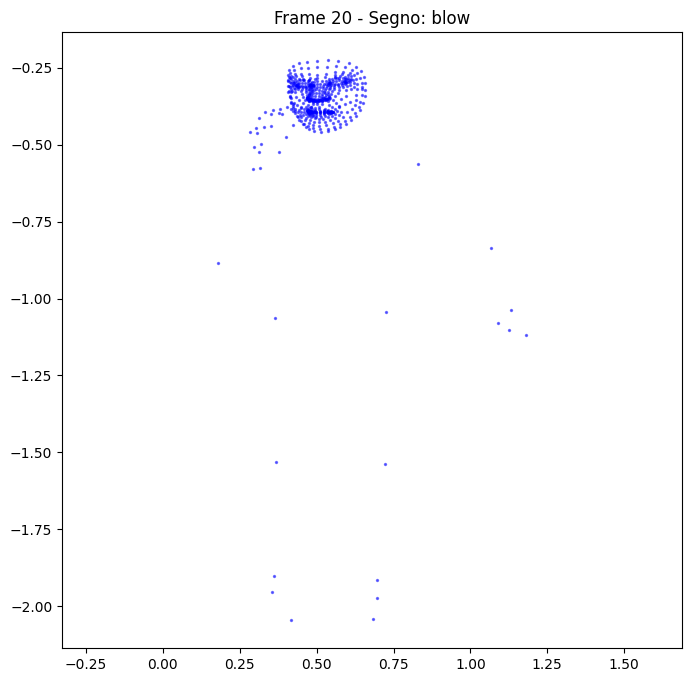

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Usa il percorso del dataset scaricato precedentemente
# path = kagglehub.competition_download('asl-signs')

# Carichiamo il file train.csv per trovare un parquet di esempio
train_csv_path = os.path.join(path, 'train.csv')
if os.path.exists(train_csv_path):
    df = pd.read_csv(train_csv_path)

    # Prendiamo il primo elemento
    sample_row = df.iloc[0]
    sample_parquet_path = os.path.join(path, sample_row['path'])
    sample_sign = sample_row['sign']

    print(f"Visualizzazione per il segno: {sample_sign}")

    # Leggiamo il parquet
    parquet_df = pd.read_parquet(sample_parquet_path)

    # Filtriamo per un frame specifico (es. il primo frame disponibile)
    first_frame = parquet_df['frame'].min()
    frame_data = parquet_df[parquet_df['frame'] == first_frame]

    # Creiamo un plot semplice dei punti (landmark)
    plt.figure(figsize=(8, 8))

    # Filtriamo via i valori NaN
    frame_data = frame_data.dropna(subset=['x', 'y'])

    # Disegniamo i punti. Invertiamo l'asse Y per avere l'orientamento corretto dell'immagine
    plt.scatter(frame_data['x'], -frame_data['y'], s=2, c='blue', alpha=0.5)
    plt.title(f"Frame {first_frame} - Segno: {sample_sign}")
    plt.axis('equal')
    plt.show()
else:
    print("File train.csv non trovato nel percorso del dataset.")


In [ ]:
# Download custom TFRecords datasets provided by the author
try:
    print("Starting loading Dataset...")

    # Download 5-fold dataset
    path_5fold = kagglehub.dataset_download('hoyso48/islr-5fold')
    print("Path to 5fold files:", path_5fold)

    # Download 5-fold random split dataset
    path_5fold_randsplit = kagglehub.dataset_download('hoyso48/islr-5fold-randsplit')
    print("Path to 5fold randsplit files:", path_5fold_randsplit)
    # ------------------------------------------------

    print("Operation completed!")
    send_email_notification(
        subject="Colab: Part 2 of the Dataset loaded!",
        body="The second part of the Dataset has been successfully loaded",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

except Exception as e:
    print(f"Operation aborted! Error:\n\n{e}")
    send_email_notification(
        subject="Colab: Error while loading the part 2 of the Dataset",
        body=f"Error:\n\n{e}",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

Starting loading Dataset...
Using Colab cache for faster access to the 'islr-5fold' dataset.
Path to 5fold files: /kaggle/input/islr-5fold
Using Colab cache for faster access to the 'islr-5fold-randsplit' dataset.
Path to 5fold randsplit files: /kaggle/input/islr-5fold-randsplit
Operation completed!
✅ Email notification successfully sent to: davidefileccia113@gmail.com


In [ ]:
import glob

# Set paths based on the folders downloaded via kagglehub
COMPETITION_PATH = path # Variable from the previous cell (asl-signs)
FOLD_5_PATH = path_5fold

# Find all tfrecords files in the downloaded local folder
TRAIN_FILENAMES = glob.glob(FOLD_5_PATH + '/*.tfrecords')

print(f"Found {len(TRAIN_FILENAMES)} tfrecords files.")

# Copy the necessary files to the current directory (expected by later code)
!cp {COMPETITION_PATH}/train.csv .
!cp {COMPETITION_PATH}/sign_to_prediction_index_map.json .

Found 187 tfrecords files.


## Dataset Analysis

Here we analyze `train.csv`.

In [9]:
# Train DataFrame
train_df = pd.read_csv('train.csv')
display(train_df.head())
display(train_df.info())

,path,participant_id,sequence_id,sign
0,train_landmark_files/26734/1000035562.parquet,26734,1000035562,blow
1,train_landmark_files/28656/1000106739.parquet,28656,1000106739,wait
2,train_landmark_files/16069/100015657.parquet,16069,100015657,cloud
3,train_landmark_files/25571/1000210073.parquet,25571,1000210073,bird
4,train_landmark_files/62590/1000240708.parquet,62590,1000240708,owie


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.9+ MB


None

In [10]:
import re
def count_data_items(filenames):
    n = [int(re.compile(r"-([0-9]*)\.").search(filename.split('/')[-1]).group(1)) for filename in filenames]
    return np.sum(n)
print(count_data_items(TRAIN_FILENAMES), len(train_df))
assert count_data_items(TRAIN_FILENAMES) == len(train_df)

NameError: name 'TRAIN_FILENAMES' is not defined

In [3]:
ROWS_PER_FRAME = 543
MAX_LEN = 384
CROP_LEN = MAX_LEN
NUM_CLASSES  = 250
PAD = -100.
NOSE=[
    1,2,98,327
]
LNOSE = [98]
RNOSE = [327]
LIP = [ 0,
    61, 185, 40, 39, 37, 267, 269, 270, 409,
    291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
    95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
]
LLIP = [84,181,91,146,61,185,40,39,37,87,178,88,95,78,191,80,81,82]
RLIP = [314,405,321,375,291,409,270,269,267,317,402,318,324,308,415,310,311,312]

POSE = [500, 502, 504, 501, 503, 505, 512, 513]
LPOSE = [513,505,503,501]
RPOSE = [512,504,502,500]

REYE = [
    33, 7, 163, 144, 145, 153, 154, 155, 133,
    246, 161, 160, 159, 158, 157, 173,
]
LEYE = [
    263, 249, 390, 373, 374, 380, 381, 382, 362,
    466, 388, 387, 386, 385, 384, 398,
]

LHAND = np.arange(468, 489).tolist()
RHAND = np.arange(522, 543).tolist()

POINT_LANDMARKS = LIP + LHAND + RHAND + NOSE + REYE + LEYE #+POSE

NUM_NODES = len(POINT_LANDMARKS)
CHANNELS = 6*NUM_NODES

print(NUM_NODES)
print(CHANNELS)

def interp1d_(x, target_len, method='random'):
    length = tf.shape(x)[1]
    target_len = tf.maximum(1,target_len)
    if method == 'random':
        if tf.random.uniform(()) < 0.33:
            x = tf.image.resize(x, (target_len,tf.shape(x)[1]),'bilinear')
        else:
            if tf.random.uniform(()) < 0.5:
                x = tf.image.resize(x, (target_len,tf.shape(x)[1]),'bicubic')
            else:
                x = tf.image.resize(x, (target_len,tf.shape(x)[1]),'nearest')
    else:
        x = tf.image.resize(x, (target_len,tf.shape(x)[1]),method)
    return x

def tf_nan_mean(x, axis=0, keepdims=False):
    return tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), x), axis=axis, keepdims=keepdims) / tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), tf.ones_like(x)), axis=axis, keepdims=keepdims)

def tf_nan_std(x, center=None, axis=0, keepdims=False):
    if center is None:
        center = tf_nan_mean(x, axis=axis,  keepdims=True)
    d = x - center
    return tf.math.sqrt(tf_nan_mean(d * d, axis=axis, keepdims=keepdims))

class Preprocess(tf.keras.layers.Layer):
    def __init__(self, max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.point_landmarks = point_landmarks

    def call(self, inputs):
        if len(inputs.shape) == 3:
            x = inputs[None,...]
        else:
            x = inputs

        mean = tf_nan_mean(tf.gather(x, [17], axis=2), axis=[1,2], keepdims=True)
        mean = tf.where(tf.math.is_nan(mean), tf.constant(0.5,x.dtype), mean)
        x = tf.gather(x, self.point_landmarks, axis=2) #N,T,P,C
        std = tf_nan_std(x, center=mean, axis=[1,2], keepdims=True)

        x = (x - mean)/std

        if self.max_len is not None:
            x = x[:,:self.max_len]
        length = tf.shape(x)[1]
        x = x[...,:2]

        dx = tf.cond(tf.shape(x)[1]>1,lambda:tf.pad(x[:,1:] - x[:,:-1], [[0,0],[0,1],[0,0],[0,0]]),lambda:tf.zeros_like(x))

        dx2 = tf.cond(tf.shape(x)[1]>2,lambda:tf.pad(x[:,2:] - x[:,:-2], [[0,0],[0,2],[0,0],[0,0]]),lambda:tf.zeros_like(x))

        x = tf.concat([
            tf.reshape(x, (-1,length,2*len(self.point_landmarks))),
            tf.reshape(dx, (-1,length,2*len(self.point_landmarks))),
            tf.reshape(dx2, (-1,length,2*len(self.point_landmarks))),
        ], axis = -1)

        x = tf.where(tf.math.is_nan(x),tf.constant(0.,x.dtype),x)

        return x

118
708


### Struttura dei TFRecord

I file TFRecord (`.tfrecords`) sono un formato binario ottimizzato per TensorFlow, che consente un I/O efficiente. In questo notebook, ogni record TFRecord contiene le seguenti caratteristiche, come definito nella funzione `decode_tfrec`:

- **`coordinates`**: Una stringa di byte che, una volta decodificata, rappresenta le coordinate dei landmark per ogni frame di un gesto.
  - È una sequenza di frame, dove ogni frame ha `ROWS_PER_FRAME` (543) landmark, e ogni landmark ha 3 coordinate (x, y, z).
  - La forma decodificata è `(-1, ROWS_PER_FRAME, 3)`, dove `-1` indica la dimensione temporale (numero di frame).
- **`sign`**: Un intero che rappresenta l'indice numerico del segno della lingua dei segni americana (ASL) a cui appartiene la sequenza.

Questa struttura permette di caricare in modo efficiente le sequenze di landmark e le etichette corrispondenti per l'addestramento del modello.

In [11]:
def decode_tfrec(record_bytes):
    features = tf.io.parse_single_example(record_bytes, {
        'coordinates': tf.io.FixedLenFeature([], tf.string),
        'sign': tf.io.FixedLenFeature([], tf.int64),
    })
    out = {}
    out['coordinates']  = tf.reshape(tf.io.decode_raw(features['coordinates'], tf.float32), (-1,ROWS_PER_FRAME,3))
    out['sign'] = features['sign']
    return out

def filter_nans_tf(x, ref_point=POINT_LANDMARKS):
    mask = tf.math.logical_not(tf.reduce_all(tf.math.is_nan(tf.gather(x,ref_point,axis=1)), axis=[-2,-1]))
    x = tf.boolean_mask(x, mask, axis=0)
    return x

def preprocess(x, augment=False, max_len=MAX_LEN):
    coord = x['coordinates']
    coord = filter_nans_tf(coord)
    if augment:
        coord = augment_fn(coord, max_len=max_len)
    coord = tf.ensure_shape(coord, (None,ROWS_PER_FRAME,3))

    return tf.cast(Preprocess(max_len=max_len)(coord)[0],tf.float32), tf.one_hot(x['sign'], NUM_CLASSES)

def flip_lr(x):
    x,y,z = tf.unstack(x, axis=-1)
    x = 1-x
    new_x = tf.stack([x,y,z], -1)
    new_x = tf.transpose(new_x, [1,0,2])
    lhand = tf.gather(new_x, LHAND, axis=0)
    rhand = tf.gather(new_x, RHAND, axis=0)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(LHAND)[...,None], rhand)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(RHAND)[...,None], lhand)
    llip = tf.gather(new_x, LLIP, axis=0)
    rlip = tf.gather(new_x, RLIP, axis=0)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(LLIP)[...,None], rlip)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(RLIP)[...,None], llip)
    lpose = tf.gather(new_x, LPOSE, axis=0)
    rpose = tf.gather(new_x, RPOSE, axis=0)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(LPOSE)[...,None], rpose)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(RPOSE)[...,None], lpose)
    leye = tf.gather(new_x, LEYE, axis=0)
    reye = tf.gather(new_x, REYE, axis=0)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(LEYE)[...,None], reye)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(REYE)[...,None], leye)
    lnose = tf.gather(new_x, LNOSE, axis=0)
    rnose = tf.gather(new_x, RNOSE, axis=0)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(LNOSE)[...,None], rnose)
    new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(RNOSE)[...,None], lnose)
    new_x = tf.transpose(new_x, [1,0,2])
    return new_x

def resample(x, rate=(0.8,1.2)):
    rate = tf.random.uniform((), rate[0], rate[1])
    length = tf.shape(x)[0]
    new_size = tf.cast(rate*tf.cast(length,tf.float32), tf.int32)
    new_x = interp1d_(x, new_size)
    return new_x

def spatial_random_affine(xyz,
    scale  = (0.8,1.2),
    shear = (-0.15,0.15),
    shift  = (-0.1,0.1),
    degree = (-30,30),
):
    center = tf.constant([0.5,0.5])
    if scale is not None:
        scale = tf.random.uniform((),*scale)
        xyz = scale*xyz

    if shear is not None:
        xy = xyz[...,:2]
        z = xyz[...,2:]
        shear_x = shear_y = tf.random.uniform((),*shear)
        if tf.random.uniform(()) < 0.5:
            shear_x = 0.
        else:
            shear_y = 0.
        shear_mat = tf.identity([
            [1.,shear_x],
            [shear_y,1.]
        ])
        xy = xy @ shear_mat
        center = center + [shear_y, shear_x]
        xyz = tf.concat([xy,z], axis=-1)

    if degree is not None:
        xy = xyz[...,:2]
        z = xyz[...,2:]
        xy -= center
        degree = tf.random.uniform((),*degree)
        radian = degree/180*np.pi
        c = tf.math.cos(radian)
        s = tf.math.sin(radian)
        rotate_mat = tf.identity([
            [c,s],
            [-s, c],
        ])
        xy = xy @ rotate_mat
        xy = xy + center
        xyz = tf.concat([xy,z], axis=-1)

    if shift is not None:
        shift = tf.random.uniform((),*shift)
        xyz = xyz + shift

    return xyz

def temporal_crop(x, length=MAX_LEN):
    l = tf.shape(x)[0]
    offset = tf.random.uniform((), 0, tf.clip_by_value(l-length,1,length), dtype=tf.int32)
    x = x[offset:offset+length]
    return x

def temporal_mask(x, size=(0.2,0.4), mask_value=float('nan')):
    l = tf.shape(x)[0]
    mask_size = tf.random.uniform((), *size)
    mask_size = tf.cast(tf.cast(l, tf.float32) * mask_size, tf.int32)
    mask_offset = tf.random.uniform((), 0, tf.clip_by_value(l-mask_size,1,l), dtype=tf.int32)
    x = tf.tensor_scatter_nd_update(x,tf.range(mask_offset, mask_offset+mask_size)[...,None],tf.fill([mask_size,543,3],mask_value))
    return x

def spatial_mask(x, size=(0.2,0.4), mask_value=float('nan')):
    mask_offset_y = tf.random.uniform(())
    mask_offset_x = tf.random.uniform(())
    mask_size = tf.random.uniform((), *size)
    mask_x = (mask_offset_x<x[...,0]) & (x[...,0] < mask_offset_x + mask_size)
    mask_y = (mask_offset_y<x[...,1]) & (x[...,1] < mask_offset_y + mask_size)
    mask = mask_x & mask_y
    x = tf.where(mask[...,None], mask_value, x)
    return x

def augment_fn(x, always=False, max_len=None):
    if tf.random.uniform(())<0.8 or always:
        x = resample(x, (0.5,1.5))
    if tf.random.uniform(())<0.5 or always:
        x = flip_lr(x)
    if max_len is not None:
        x = temporal_crop(x, max_len)
    if tf.random.uniform(())<0.75 or always:
        x = spatial_random_affine(x)
    if tf.random.uniform(())<0.5 or always:
        x = temporal_mask(x)
    if tf.random.uniform(())<0.5 or always:
        x = spatial_mask(x)
    return x

def get_tfrec_dataset(tfrecords, batch_size=64, max_len=64, drop_remainder=False, augment=False, shuffle=False, repeat=False):
    # Initialize dataset with TFRecords
    ds = tf.data.TFRecordDataset(tfrecords, num_parallel_reads=tf.data.AUTOTUNE, compression_type='GZIP')
    ds = ds.map(decode_tfrec, tf.data.AUTOTUNE)
    ds = ds.map(lambda x: preprocess(x, augment=augment, max_len=max_len), tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    if shuffle:
        ds = ds.shuffle(shuffle)
        options = tf.data.Options()
        options.experimental_deterministic = (False)
        ds = ds.with_options(options)

    if batch_size:
        ds = ds.padded_batch(batch_size, padding_values=PAD, padded_shapes=([max_len,CHANNELS],[NUM_CLASSES]), drop_remainder=drop_remainder)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

ds = get_tfrec_dataset(TRAIN_FILENAMES, augment=True, batch_size=1024)
for x in ds:
    temp_train = x
    break

NameError: name 'TRAIN_FILENAMES' is not defined

<_ParallelMapDataset element_spec={'coordinates': TensorSpec(shape=(None, 543, 3), dtype=tf.float32, name=None), 'sign': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


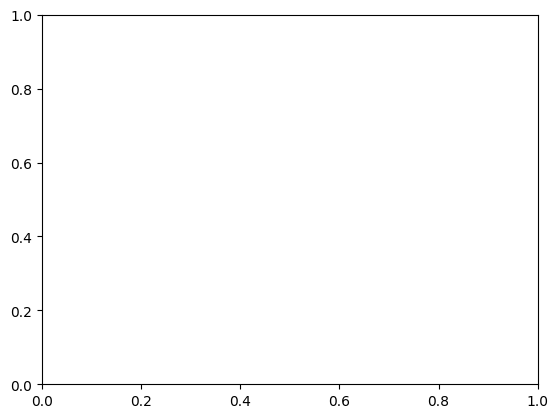

In [ ]:
from IPython.display import HTML
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

def filter_nans(frames):
    return frames[~np.isnan(frames).all(axis=(-2,-1))]

ds = tf.data.TFRecordDataset(TRAIN_FILENAMES, num_parallel_reads=tf.data.AUTOTUNE, compression_type='GZIP')
ds = ds.map(decode_tfrec, tf.data.AUTOTUNE)
print(ds)
for x in ds:
    temp = x['coordinates'].numpy()
    if not len(filter_nans(temp[:,LHAND])) == 0:
        break

edges = [(0,1),(1,2),(2,3),(3,4),(0,5),(0,17),(5,6),(6,7),(7,8),(5,9),(9,10),(10,11),(11,12),
         (9,13),(13,14),(14,15),(15,16),(13,17),(17,18),(18,19),(19,20)]

fig, ax = plt.subplots()

def plot_frame(frame, edges=[], idxs=[]):

    frame[np.isnan(frame)] = 0
    x = list(frame[...,0])
    y = list(frame[...,1])
    if len(idxs) == 0:
        idxs = list(range(len(x)))
    ax.clear()
    ax.scatter(x, y, color='dodgerblue')
    for i in range(len(x)):
        ax.text(x[i], y[i], idxs[i])

    for edge in edges:
        ax.plot([x[edge[0]], x[edge[1]]], [y[edge[0]], y[edge[1]]], color='salmon')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

def animate_frames(frames, edges=[], idxs=[]):
    anim = FuncAnimation(fig, lambda frame: plot_frame(frame, edges, idxs), frames=frames, interval=100)
    return HTML(anim.to_jshtml())

In [ ]:
# Animate the frames
if SHOW_PLOT:
    display(animate_frames(filter_nans(temp[:,LHAND]),edges=edges))

In [ ]:
if SHOW_PLOT:
    display(animate_frames(filter_nans(augment_fn(temp,always=True).numpy()[:,RHAND]),edges=edges))

In [ ]:
if SHOW_PLOT:
    display(animate_frames(filter_nans(temp[:,POINT_LANDMARKS])))

In [ ]:
if SHOW_PLOT:
    display(animate_frames(filter_nans(augment_fn(temp,always=True).numpy()[:,POINT_LANDMARKS]), idxs=POINT_LANDMARKS))

## Model Building

In [ ]:
class ECA(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv1D(1, kernel_size=kernel_size, strides=1, padding="same", use_bias=False)

    def call(self, inputs, mask=None):
        nn = tf.keras.layers.GlobalAveragePooling1D()(inputs, mask=mask)
        nn = tf.expand_dims(nn, -1)
        nn = self.conv(nn)
        nn = tf.squeeze(nn, -1)
        nn = tf.nn.sigmoid(nn)
        nn = nn[:,None,:]
        return inputs * nn

class LateDropout(tf.keras.layers.Layer):
    def __init__(self, rate, noise_shape=None, start_step=0, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.rate = rate
        self.start_step = start_step
        self.dropout = tf.keras.layers.Dropout(rate, noise_shape=noise_shape)

    def build(self, input_shape):
        super().build(input_shape)
        agg = tf.VariableAggregation.ONLY_FIRST_REPLICA
        self._train_counter = tf.Variable(0, dtype="int64", aggregation=agg, trainable=False)

    def call(self, inputs, training=False):
        x = tf.cond(self._train_counter < self.start_step, lambda:inputs, lambda:self.dropout(inputs, training=training))
        if training:
            self._train_counter.assign_add(1)
        return x

class CausalDWConv1D(tf.keras.layers.Layer):
    def __init__(self,
        kernel_size=17,
        dilation_rate=1,
        use_bias=False,
        depthwise_initializer='glorot_uniform',
        name='', **kwargs):
        super().__init__(name=name,**kwargs)
        self.causal_pad = tf.keras.layers.ZeroPadding1D((dilation_rate*(kernel_size-1),0),name=name + '_pad')
        self.dw_conv = tf.keras.layers.DepthwiseConv1D(
                            kernel_size,
                            strides=1,
                            dilation_rate=dilation_rate,
                            padding='valid',
                            use_bias=use_bias,
                            depthwise_initializer=depthwise_initializer,
                            name=name + '_dwconv')
        self.supports_masking = True

    def call(self, inputs):
        x = self.causal_pad(inputs)
        x = self.dw_conv(x)
        return x

def Conv1DBlock(channel_size,
          kernel_size,
          dilation_rate=1,
          drop_rate=0.0,
          expand_ratio=2,
          se_ratio=0.25,
          activation='swish',
          name=None):
    '''
    efficient conv1d block, @hoyso48
    '''
    if name is None:
        name = str(tf.keras.backend.get_uid("mbblock"))
    # Expansion phase
    def apply(inputs):
        channels_in = tf.keras.backend.int_shape(inputs)[-1]
        channels_expand = channels_in * expand_ratio

        skip = inputs

        x = tf.keras.layers.Dense(
            channels_expand,
            use_bias=True,
            activation=activation,
            name=name + '_expand_conv')(inputs)

        # Depthwise Convolution
        x = CausalDWConv1D(kernel_size,
            dilation_rate=dilation_rate,
            use_bias=False,
            name=name + '_dwconv')(x)

        x = tf.keras.layers.BatchNormalization(momentum=0.95, name=name + '_bn')(x)

        x  = ECA()(x)

        x = tf.keras.layers.Dense(
            channel_size,
            use_bias=True,
            name=name + '_project_conv')(x)

        if drop_rate > 0:
            x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1), name=name + '_drop')(x)

        if (channels_in == channel_size):
            x = tf.keras.layers.add([x, skip], name=name + '_add')
        return x

    return apply

In [ ]:
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, dim=256, num_heads=4, dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.scale = self.dim ** -0.5
        self.num_heads = num_heads
        self.qkv = tf.keras.layers.Dense(3 * dim, use_bias=False)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.proj = tf.keras.layers.Dense(dim, use_bias=False)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        qkv = self.qkv(inputs)
        qkv = tf.keras.layers.Permute((2, 1, 3))(tf.keras.layers.Reshape((-1, self.num_heads, self.dim * 3 // self.num_heads))(qkv))
        q, k, v = tf.split(qkv, [self.dim // self.num_heads] * 3, axis=-1)

        attn = tf.matmul(q, k, transpose_b=True) * self.scale

        if mask is not None:
            mask = mask[:, None, None, :]

        attn = tf.keras.layers.Softmax(axis=-1)(attn, mask=mask)
        attn = self.drop1(attn)

        x = attn @ v
        x = tf.keras.layers.Reshape((-1, self.dim))(tf.keras.layers.Permute((2, 1, 3))(x))
        x = self.proj(x)
        return x


def TransformerBlock(dim=256, num_heads=4, expand=4, attn_dropout=0.2, drop_rate=0.2, activation='swish'):
    def apply(inputs):
        x = inputs
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = MultiHeadSelfAttention(dim=dim,num_heads=num_heads,dropout=attn_dropout)(x)
        x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1))(x)
        x = tf.keras.layers.Add()([inputs, x])
        attn_out = x

        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = tf.keras.layers.Dense(dim*expand, use_bias=False, activation=activation)(x)
        x = tf.keras.layers.Dense(dim, use_bias=False)(x)
        x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1))(x)
        x = tf.keras.layers.Add()([attn_out, x])
        return x
    return apply

In [ ]:
def get_model(max_len=64, dropout_step=0, dim=192):
    inp = tf.keras.Input((max_len,CHANNELS))
    x = tf.keras.layers.Masking(mask_value=PAD,input_shape=(max_len,CHANNELS))(inp)
    ksize = 17
    x = tf.keras.layers.Dense(dim, use_bias=False,name='stem_conv')(x)
    x = tf.keras.layers.BatchNormalization(momentum=0.95,name='stem_bn')(x)

    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = TransformerBlock(dim,expand=2)(x)

    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
    x = TransformerBlock(dim,expand=2)(x)

    if dim == 384: #for the 4x sized model
        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = TransformerBlock(dim,expand=2)(x)

        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = Conv1DBlock(dim,ksize,drop_rate=0.2)(x)
        x = TransformerBlock(dim,expand=2)(x)

    x = tf.keras.layers.Dense(dim*2,activation=None,name='top_conv')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = LateDropout(0.8, start_step=dropout_step)(x)
    x = tf.keras.layers.Dense(NUM_CLASSES,name='classifier')(x)
    return tf.keras.Model(inp, x)

model = get_model()
y = model(temp_train[0])
tf.keras.losses.CategoricalCrossentropy(from_logits=True)(temp_train[1],y)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '1_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '2_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/la

<tf.Tensor: shape=(), dtype=float32, numpy=5.771819114685059>

In [ ]:
#check supports_masking
for x in model.layers:
    if not x.supports_masking:
        print(x.supports_masking, x.name)

False input_layer


In [ ]:
def train_fold(CFG, fold, train_files, valid_files=None, strategy=STRATEGY, summary=True):
    seed_everything(CFG.seed)
    tf.keras.backend.clear_session()
    gc.collect()
    tf.config.optimizer.set_jit(True)

    if CFG.fp16:
        try:
            policy = mixed_precision.Policy('mixed_bfloat16')
            mixed_precision.set_global_policy(policy)
        except:
            policy = mixed_precision.Policy('mixed_float16')
            mixed_precision.set_global_policy(policy)
    else:
        policy = mixed_precision.Policy('float32')
        mixed_precision.set_global_policy(policy)

    if fold != 'all':
        train_ds = get_tfrec_dataset(train_files, batch_size=CFG.batch_size, max_len=CFG.max_len, drop_remainder=True, augment=True, repeat=True, shuffle=32768)
        valid_ds = get_tfrec_dataset(valid_files, batch_size=CFG.batch_size, max_len=CFG.max_len, drop_remainder=False, repeat=False, shuffle=False)
    else:
        train_ds = get_tfrec_dataset(train_files, batch_size=CFG.batch_size, max_len=CFG.max_len, drop_remainder=False, augment=True, repeat=True, shuffle=32768)
        valid_ds = None
        valid_files = []

    num_train = count_data_items(train_files)
    num_valid = count_data_items(valid_files)
    steps_per_epoch = num_train//CFG.batch_size
    with strategy.scope():
        dropout_step = CFG.dropout_start_epoch * steps_per_epoch
        model = get_model(max_len=CFG.max_len, dropout_step=dropout_step, dim=CFG.dim)

        # Use native CosineDecay for Keras 3 compatibility
        schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=CFG.lr,
            decay_steps=CFG.epoch * steps_per_epoch,
            alpha=CFG.lr_min / CFG.lr
        )

        awp_step = CFG.awp_start_epoch * steps_per_epoch
        if CFG.fgm:
            model = FGM(model.input, model.output, delta=CFG.awp_lambda, eps=0., start_step=awp_step)
        elif CFG.awp:
            model = AWP(model.input, model.output, delta=CFG.awp_lambda, eps=0., start_step=awp_step)

        opt = tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=CFG.weight_decay)

        model.compile(
            optimizer=opt,
            loss=[tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1)], #[tf.keras.losses.CategoricalCrossentropy(from_logits=True)],
            metrics=[
                tf.keras.metrics.CategoricalAccuracy(),
            ],
            steps_per_execution=steps_per_epoch,
        )

    if summary:
        print()
        model.summary()
        print()
        print(train_ds, valid_ds)
        print()
        init=False
    print(f'---------fold{fold}---------')
    print(f'train:{num_train} valid:{num_valid}')
    print()

    if CFG.resume:
        print(f'resume from epoch{CFG.resume}')
        model.load_weights(f'{CFG.output_dir}/{CFG.comment}-fold{fold}-last.weights.h5')
        if train_ds is not None:
            model.evaluate(train_ds.take(steps_per_epoch))
        if valid_ds is not None:
            model.evaluate(valid_ds)

    logger = tf.keras.callbacks.CSVLogger(f'{CFG.output_dir}/{CFG.comment}-fold{fold}-logs.csv')
    sv_loss = tf.keras.callbacks.ModelCheckpoint(f'{CFG.output_dir}/{CFG.comment}-fold{fold}-best.weights.h5', monitor='val_loss', verbose=0, save_best_only=True,
                save_weights_only=True, mode='min', save_freq='epoch')

    # Rimosse callback Snapshot e SWA in quanto incompatibili con Keras 3
    # snap = Snapshot(f'{CFG.output_dir}/{CFG.comment}-fold{fold}', CFG.snapshot_epochs)
    # swa = SWA(f'{CFG.output_dir}/{CFG.comment}-fold{fold}', CFG.swa_epochs, strategy=strategy, train_ds=train_ds, valid_ds=valid_ds, valid_steps=-(num_valid//-CFG.batch_size))

    callbacks = []
    if CFG.save_output:
        callbacks.append(logger)
        # callbacks.append(snap)
        # callbacks.append(swa)
        if fold != 'all':
            callbacks.append(sv_loss)

    history = model.fit(
        train_ds,
        epochs=CFG.epoch-CFG.resume,
        steps_per_epoch=steps_per_epoch,
        callbacks=callbacks,
        validation_data=valid_ds,
        verbose=CFG.verbose,
        validation_steps=-(num_valid//-CFG.batch_size)
    )

    if CFG.save_output:
        try:
            model.load_weights(f'{CFG.output_dir}/{CFG.comment}-fold{fold}-best.weights.h5')
        except:
            pass
    if fold != 'all':
        cv = model.evaluate(valid_ds,verbose=CFG.verbose,steps=-(num_valid//-CFG.batch_size))
    else:
        cv = None

    return model, cv, history

def train_folds(CFG, folds, strategy=STRATEGY, summary=True):
    for fold in folds:
        if fold != 'all':
            all_files = TRAIN_FILENAMES
            train_files = [x for x in all_files if f'fold{fold}' not in x]
            valid_files = [x for x in all_files if f'fold{fold}' in x]
        else:
            train_files = TRAIN_FILENAMES
            valid_files = None

        train_fold(CFG, fold, train_files, valid_files, strategy=strategy, summary=summary)
    return


In [ ]:
class CFG:
    n_splits = 5
    save_output = True
    output_dir = '/content/drive/MyDrive/MITA ANN weights' # Modificato da '/kaggle/working' per Colab

    seed = 42
    verbose = 2 #0) silent 1) progress bar 2) one line per epoch

    max_len = 384
    replicas = N_REPLICAS # Utilizziamo la variabile globale definita in precedenza
    lr = 5e-4 * replicas
    weight_decay = 0.1
    lr_min = 1e-6
    epoch = 300 #400
    warmup = 0
    batch_size = 64 * replicas
    snapshot_epochs = []
    swa_epochs = [] #list(range(epoch//2,epoch+1))

    fp16 = True
    fgm = False
    awp = False
    awp_lambda = 0.2
    awp_start_epoch = 15
    dropout_start_epoch = 15
    resume = 0
    decay_type = 'cosine'
    dim = 192
    comment = f'islr-fp16-192-8-seed{seed}'

In [ ]:
try:
    print("Training started...")
    if TRAININING:
      train_folds(CFG, [0])
    # ------------------------------------------------

    print("Operation completed")
    send_email_notification(
        subject="Colab: Training completed!",
        body="Il modello ha finito di addestrarsi con successo. Vai su Colab per salvare i risultati!",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

except Exception as e:
    print(f"Si è verificato un errore: {e}")
    send_email_notification(
        subject="Colab: Training error!",
        body=f"L'esecuzione si è interrotta a causa del seguente errore:\n\n{e}",
        sender_email=SENDER_EMAIL,
        app_password=APP_PASSWORD,
        receiver_email=RECEIVER_EMAIL
    )

Training started...
Operation completed
✅ Email notification successfully sent to: davidefileccia113@gmail.com


### Test del Modello (Inferenza)
Carichiamo i pesi appena salvati e proviamo a fare una predizione su un singolo esempio.

In [ ]:
import json
import numpy as np
import tensorflow as tf

# 1. Inizializza l'architettura del modello
inference_model = get_model(max_len=CFG.max_len, dropout_step=0, dim=CFG.dim)

# 2. Carica i pesi appena addestrati dal tuo Google Drive
# Usiamo .weights.h5 se hai addestrato in Keras 3, altrimenti .h5
weights_path = f'{CFG.output_dir}/{CFG.comment}-fold0-best.weights.h5'
print(f"Provo a caricare i pesi da: {weights_path}")

try:
    # skip_mismatch=True aiuta se ci sono piccolissime differenze non critiche
    inference_model.load_weights(weights_path, skip_mismatch=True)
    print("✅ Pesi caricati con successo!")
except Exception as e:
    print(f"❌ Errore nel caricamento dei pesi: {e}")
    # Fallback al file .h5 nel caso
    try:
        fallback_path = f'{CFG.output_dir}/{CFG.comment}-fold0-best.h5'
        print(f"Provo il fallback da: {fallback_path}")
        inference_model.load_weights(fallback_path, skip_mismatch=True)
        print("✅ Pesi caricati con successo (fallback)!")
    except Exception as e2:
        print(f"❌ Fallito anche il fallback: {e2}")

# 3. Carica il dizionario per mappare gli indici ai nomi dei segni
try:
    with open('sign_to_prediction_index_map.json', 'r') as f:
        sign_map = json.load(f)
    index_to_sign = {v: k for k, v in sign_map.items()}
except FileNotFoundError:
    print("Attenzione: file sign_to_prediction_index_map.json non trovato.")
    index_to_sign = {i: f"Classe_{i}" for i in range(NUM_CLASSES)}

# 4. Prepariamo un dato di test
test_ds = get_tfrec_dataset(TRAIN_FILENAMES, batch_size=1, max_len=CFG.max_len, drop_remainder=False, augment=False, shuffle=False)

for x, y in test_ds.take(1):
    sample_input = x
    true_label_index = tf.argmax(y[0]).numpy()
    break

# 5. Fai la predizione
print("\nAvvio predizione...")
predictions = inference_model.predict(sample_input)
predicted_index = tf.argmax(predictions, axis=1).numpy()[0]

# 6. Mostra i risultati
print("-" * 30)
print(f"🎯 Segno Reale:    {index_to_sign[true_label_index]} (Indice: {true_label_index})")
print(f"🤖 Segno Predetto: {index_to_sign[predicted_index]} (Indice: {predicted_index})")
print("-" * 30)

predicted_prob = tf.nn.softmax(predictions[0])[predicted_index].numpy() * 100
print(f"Confidenza del modello: {predicted_prob:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Provo a caricare i pesi da: /content/drive/MyDrive/MITA ANN weights/islr-fp16-192-8-seed42-fold0-best.weights.h5
✅ Pesi caricati con successo!

Avvio predizione...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '13_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '14_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '15_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
------------------------------
🎯 Segno Reale:    jump (Indice: 127)
🤖 Segno Predetto: jump (Indice: 127)
------------------------------
Confidenza del modello: 83.80%


In [ ]:
from google.colab import files

# Scegli il nome del file da salvare
model_filename = 'asl_model_complete.keras'

# Salva il modello completo (architettura + pesi)
print("Salvataggio del modello in corso...")
inference_model.save(model_filename)
print(f"✅ Modello salvato con successo come {model_filename}")

# Avvia il download sul tuo computer
print("Avvio del download...")
files.download(model_filename)


Salvataggio del modello in corso...
✅ Modello salvato con successo come asl_model_complete.keras
Avvio del download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7. Esportazione come Black Box (SavedModel)
Esegui questa cella per esportare il modello in un formato indipendente dal codice Python originale (SavedModel). Verrà scaricato un file `.zip`.

In [64]:
import tensorflow as tf
import shutil
from google.colab import files
import os

export_dir = 'asl_pure_tf_blackbox'

print(f"Esportazione in {export_dir}...")
try:
    # Usa il metodo nativo di Keras 3 per esportare un SavedModel di sola inferenza (blackbox)
    inference_model.export(export_dir)
    print("\u2705 Modello esportato con successo come Grafo TensorFlow puro (Vera Black Box)!")

    # Comprimiamo la cartella in un file .zip
    shutil.make_archive(export_dir, 'zip', export_dir)
    print(f"\u2705 Cartella zippata creata: {export_dir}.zip")

    # Avvia il download
    print("Avvio del download...")
    files.download(f'{export_dir}.zip')

except Exception as e:
    print(f"\u274c Errore durante l'esportazione: {e}")

Esportazione in asl_pure_tf_blackbox...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '13_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '14_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer '15_dwconv_pad' (of type ZeroPadding1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local

Saved artifact at 'asl_pure_tf_blackbox'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 708), dtype=tf.float32, name='keras_tensor_188')
Output Type:
  TensorSpec(shape=(None, 250), dtype=tf.float32, name=None)
Captures:
  135275598277968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598279312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598279120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598278544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598279696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598277776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598278736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598280464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598281232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135275598281040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1352755

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 8. Testing Live con Fotocamera

Questa sezione ti permetterà di utilizzare la tua webcam per catturare i segni ASL in tempo reale, elaborare i landmark con MediaPipe e inviarli al modello per la predizione. Il modello e le funzioni di pre-elaborazione sono già stati caricati e configurati nelle celle precedenti.

In [3]:
!pip install -q mediapipe

In [2]:
!pip install --upgrade protobuf
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14

print("Installazione completata. ORA DEVI RIAVVIARE IL RUNTIME (Runtime > Riavvia sessione).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.1 which is incompatible.
google-cloud-aiplatform 1.148.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.34.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobu

Installazione completata. ORA DEVI RIAVVIARE IL RUNTIME (Runtime > Riavvia sessione).


In [2]:
!pip install tensorflow==2.16.1
!pip install mediapipe==0.10.14
!pip install protobuf==4.25.3

print("\n✅ Installazione completata! ORA RIAVVIA IL RUNTIME (Runtime > Riavvia sessione).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 127.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.16.1 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.4 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21


✅ Installazione completata! ORA RIAVVIA IL RUNTIME (Runtime > Riavvia sessione).


In [2]:
!pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompati

In [1]:

import tensorflow as tf
import zipfile
import os

zip_filename = 'asl_pure_tf_blackbox.zip'
extract_dir = 'asl_pure_tf_blackbox_extracted'

# Cerca il file in locale o su Google Drive
percorsi_possibili = [
    f'./{zip_filename}',
    f'/content/drive/MyDrive/Model/{zip_filename}'
]

zip_path_trovato = None
for p in percorsi_possibili:
    if os.path.exists(p):
        zip_path_trovato = p
        break

if zip_path_trovato:
    print(f"File '{zip_filename}' trovato in: {zip_path_trovato}")
    print(f"Estrazione in corso...")
    try:
        with zipfile.ZipFile(zip_path_trovato, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("\u2705 Estrazione completata!")

        print("Caricamento del SavedModel in corso...")
        # Carica la scatola nera
        blackbox_model = tf.saved_model.load(extract_dir)

        # Ottieni la funzione di inferenza
        inference_model = blackbox_model.signatures['serve']
        print("\u2705 Modello blackbox caricato con successo e pronto per l'inferenza live!")
    except Exception as e:
        print(f"\u274c Errore nel caricamento del modello: {e}")
else:
    print(f"\u274c File '{zip_filename}' non trovato né in locale né su Drive. Assicurati di averlo caricato!")

File 'asl_pure_tf_blackbox.zip' trovato in: /content/drive/MyDrive/Model/asl_pure_tf_blackbox.zip
Estrazione in corso...
✅ Estrazione completata!
Caricamento del SavedModel in corso...
✅ Modello blackbox caricato con successo e pronto per l'inferenza live!


In [ ]:
import cv2
import mediapipe as mp
import json
import time

# Workaround per il problema di importazione in Colab
if not hasattr(mp, 'solutions'):
    import mediapipe.python.solutions as solutions
    mp.solutions = solutions

from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import tensorflow as tf

# Carica il dizionario per mappare gli indici ai nomi dei segni
try:
    with open('sign_to_prediction_index_map.json', 'r') as f:
        sign_map = json.load(f)
    index_to_sign = {v: k for k, v in sign_map.items()}
except FileNotFoundError:
    print("Attenzione: file sign_to_prediction_index_map.json non trovato.")
    index_to_sign = {i: f"Classe_{i}" for i in range(NUM_CLASSES)}

# Inizializza MediaPipe Holistic (o Hands, a seconda del modello)
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# --- Configurazione del pre-processamento per i dati live ---
# Si assicura che il preprocessore sia lo stesso dell'addestramento
# Le classi Preprocess, tf_nan_mean, tf_nan_std sono già definite nelle celle precedenti.

def live_preprocess(landmarks_sequence, max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS):
    # Converti la lista di landmark in un tensore TensorFlow
    if not landmarks_sequence:
        return tf.constant([], dtype=tf.float32)

    # Converte la sequenza di landmark in un array numpy
    np_landmarks = np.array(landmarks_sequence, dtype=np.float32)

    # Assicurati che la forma sia (num_frames, ROWS_PER_FRAME, 3)
    processed_landmarks = np.full((np_landmarks.shape[0], ROWS_PER_FRAME, 3), np.nan, dtype=np.float32)

    processed_landmarks[:, :np_landmarks.shape[1], :] = np_landmarks

    tf_landmarks = tf.convert_to_tensor(processed_landmarks[tf.newaxis, ...], dtype=tf.float32) # Aggiungi dimensione batch

    # Applica la classe Preprocess
    preprocessed_input = Preprocess(max_len=max_len, point_landmarks=point_landmarks)(tf_landmarks)
    return preprocessed_input

# Funzioni per la cattura e visualizzazione della webcam
def video_stream():
    js = Javascript('''
        var video;
        var div = null;
        var stream;
        var captureCanvas;
        var imgElement;
        var setupDone = false;

        var shutdown = false;

        function setup() {
            return new Promise(function(resolve, reject) {
                if (setupDone) { resolve(); return; }
                setupDone = true;
                div = document.createElement('div');
                document.body.appendChild(div);

                video = document.createElement('video');
                video.style.display = 'block';
                div.appendChild(video);

                captureCanvas = document.createElement('canvas');
                captureCanvas.style.display = 'none';
                div.appendChild(captureCanvas);

                imgElement = document.createElement('img');
                imgElement.style.display = 'none';
                div.appendChild(imgElement);

                var constraints = { video: true };
                navigator.mediaDevices.getUserMedia(constraints).then(function(s) {
                    stream = s;
                    video.srcObject = s;
                    video.onloadedmetadata = function(e) {
                        video.play();
                        resolve();
                    };
                }).catch(function(err) {
                    console.error("Errore webcam:", err);
                    reject(err);
                });

                google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            });
        }

        function capture() {
            return new Promise(function(resolve) {
                if (!video || !stream) {
                    resolve({img: "", width: 0, height: 0});
                    return;
                }
                captureCanvas.width = video.videoWidth;
                captureCanvas.height = video.videoHeight;
                captureCanvas.getContext('2d').drawImage(video, 0, 0, video.videoWidth, video.videoHeight);
                var dataUrl = captureCanvas.toDataURL('image/jpeg', 0.8);
                resolve({img: dataUrl, width: video.videoWidth, height: video.videoHeight});
            });
        }

        function stop() {
            if (!shutdown) {
              shutdown = true;
              if (stream) {
                  stream.getVideoTracks()[0].stop();
              }
              if (video) video.remove();
              if (div) div.remove();
              video = null;
              div = null;
              stream = null;
              captureCanvas = null;
              imgElement = null;
            }
        }
        ''')
    display(js)

def video_frame(quality=0.8, vwidth=480, vheight=360):
    data = eval_js('capture()')
    if not data or not data['img']:
        return None
    image_data = b64decode(data['img'].split(',')[1])
    return cv2.imdecode(np.frombuffer(image_data, np.uint8), cv2.IMREAD_COLOR)

# --- Funzione principale per il testing live ---
def start_live_testing(inference_model, index_to_sign):
    print("Avvio del testing live... Premi 'Q' nella finestra di preview per uscire (o interrompi l'esecuzione della cella).")

    # Inizializza MediaPipe Holistic
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        video_stream()

        try:
            # Attende che la webcam sia pronta tramite la Promise restituita
            eval_js('setup()')
        except Exception as e:
            print(f"Impossibile inizializzare la webcam: {e}")
            return

        # Variabili per gestire la sequenza di landmark
        sequence = []
        predictions_history = [] # Per tenere traccia delle ultime predizioni e stabilizzare l'output

        try:
            while True:
                frame = video_frame()
                if frame is None:
                    print("Errore nella cattura del frame o webcam non disponibile.")
                    break

                # Converti l'immagine da BGR a RGB (MediaPipe preferisce RGB)
                image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # Fai una copia per evitare problemi di mutabilità
                image.flags.writeable = False

                # Processa l'immagine con MediaPipe
                results = holistic.process(image)

                # Disegna i landmark
                image.flags.writeable = True
                image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

                # Estrai i landmark per il modello
                current_frame_landmarks = np.zeros((ROWS_PER_FRAME, 3), dtype=np.float32)
                current_frame_landmarks.fill(np.nan) # Inizializza con NaN

                # Popoliamo i 543 landmark usando le dimensioni esatte (Volto: 468, Posa: 33, Mani: 21 ciascuna)
                if results.face_landmarks:
                    for i, lm in enumerate(results.face_landmarks.landmark): current_frame_landmarks[i] = [lm.x, lm.y, lm.z]
                if results.pose_landmarks:
                    for i, lm in enumerate(results.pose_landmarks.landmark): current_frame_landmarks[468 + i] = [lm.x, lm.y, lm.z]
                if results.left_hand_landmarks:
                    for i, lm in enumerate(results.left_hand_landmarks.landmark): current_frame_landmarks[468 + 33 + i] = [lm.x, lm.y, lm.z]
                if results.right_hand_landmarks:
                    for i, lm in enumerate(results.right_hand_landmarks.landmark): current_frame_landmarks[468 + 33 + 21 + i] = [lm.x, lm.y, lm.z]


                # Aggiungi il frame corrente alla sequenza (se non è tutto NaN)
                if not np.all(np.isnan(current_frame_landmarks)):
                    sequence.append(current_frame_landmarks)

                # Mantieni la sequenza a una lunghezza massima per l'inferenza
                if len(sequence) > MAX_LEN:
                    sequence = sequence[-MAX_LEN:]

                if len(sequence) > 0:
                    # Pre-processa la sequenza per il modello
                    model_input = live_preprocess(sequence)

                    if model_input.shape[1] > 0: # Assicurati che ci siano dati validi
                        # Fai la predizione usando il formato SavedModel Blackbox
                        # Inference_model è una ConcreteFunction, non ha .predict()
                        outputs = inference_model(tf.constant(model_input))
                        # L'output è un dizionario. Estraiamo il tensore dei risultati
                        predictions = list(outputs.values())[0]

                        # Ottieni la probabilità e l'indice del segno predetto
                        predicted_index = tf.argmax(predictions, axis=1).numpy()[0]
                        predicted_prob = tf.nn.softmax(predictions[0])[predicted_index].numpy() * 100
                        predicted_sign = index_to_sign.get(predicted_index, 'Sconosciuto')

                        # Aggiungi alla history per stabilizzare l'output
                        predictions_history.append((predicted_sign, predicted_prob))
                        if len(predictions_history) > 5: # Mantieni una breve history
                            predictions_history.pop(0)

                        # Determina la predizione più frequente o più recente
                        current_prediction_text = f"Predetto: {predicted_sign} ({predicted_prob:.2f}%)"
                    else:
                        current_prediction_text = "Attendendo dati validi..."
                else:
                    current_prediction_text = "Attendendo sufficienti landmark..."

                # Visualizza la predizione sul frame
                cv2.putText(image, current_prediction_text, (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

                # Converti l'immagine per la visualizzazione in Colab
                _, ret_image = cv2.imencode('.jpeg', image)
                i = display(Image(data=ret_image.tobytes()))
                clear_output(wait=True)

        except KeyboardInterrupt:
            print("Testing interrotto.")
        finally:
            eval_js('stop()')
            print("Webcam spenta.")

# Esegui il testing live
from IPython.display import clear_output
start_live_testing(inference_model, index_to_sign)
